In [1]:
pip install mne numpy pandas matplotlib scipy


Note: you may need to restart the kernel to use updated packages.


In [5]:
import numpy as np
import mne
import matplotlib.pyplot as plt

# ======================
# 1. Load Sample EEG Data
# ======================

# استفاده از دیتای تست MNE (برای شروع سریع)
sample_data_folder = mne.datasets.sample.data_path()
sample_data_raw_file = sample_data_folder + '/MEG/sample/sample_audvis_raw.fif'

raw = mne.io.read_raw_fif(sample_data_raw_file, preload=True)

print(raw.info)

# ======================
# 2. انتخاب فقط EEG channels
# ======================

raw.pick_types(eeg=True)

print("Number of EEG channels:", len(raw.ch_names))

# ======================
# 3. فیلتر کردن سیگنال
# ======================

raw.filter(l_freq=0.5, h_freq=45)

# حذف نویز برق (50Hz)
raw.notch_filter(freqs=50)

# ======================
# 4. Visualization
# ======================

# نمایش چند کانال
raw.plot(n_channels=10, duration=5)

# ======================
# 5. استخراج دیتا
# ======================

data, times = raw.get_data(return_times=True)

print("EEG shape:", data.shape)

# ======================
# 6. ذخیره داده
# ======================

np.save("eeg_filtered.npy", data)

print("Preprocessing done ✅")


Using default location ~/mne_data for sample...


Failed to download 'MNE-sample-data-processed.tar.gz'. Will attempt the download again 2 more times.
 99%|##################################6| 1.64G/1.65G [5:00:25<02:51, 90.8kB/s]
Failed to download 'MNE-sample-data-processed.tar.gz'. Will attempt the download again 1 more time.
  0%|                                  | 1.71M/1.65G [00:41<11:14:07, 40.8kB/s]


HTTPError: 403 Client Error: Forbidden for url: https://osf.io/86qa2/download?version=6

C:\Users\Sazgar\anaconda3\envs\neuro\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Download complete in 09s (1.2 MB)
Extracting EDF parameters from C:\Users\Sazgar\mne_data\MNE-eegbci-data\files\eegmmidb\1.0.0\S001\S001R01.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 9759  =      0.000 ...    60.994 secs...
Data loaded
<Info | 8 non-empty values
 bads: []
 ch_names: Fc5., Fc3., Fc1., Fcz., Fc2., Fc4., Fc6., C5.., C3.., C1.., ...
 chs: 64 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 80.0 Hz
 meas_date: 2009-08-12 16:15:00 UTC
 nchan: 64
 projs: []
 sfreq: 160.0 Hz
 subject_info: 3 items (dict)
>
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
EEG channels: 64
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 45 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuati

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  64 out of  64 | elapsed:    0.0s finished


Filtering done
Using matplotlib as 2D backend.


[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  64 out of  64 | elapsed:    0.0s finished


Plot saved
EEG shape: (64, 9760)
Files saved
Done ✅


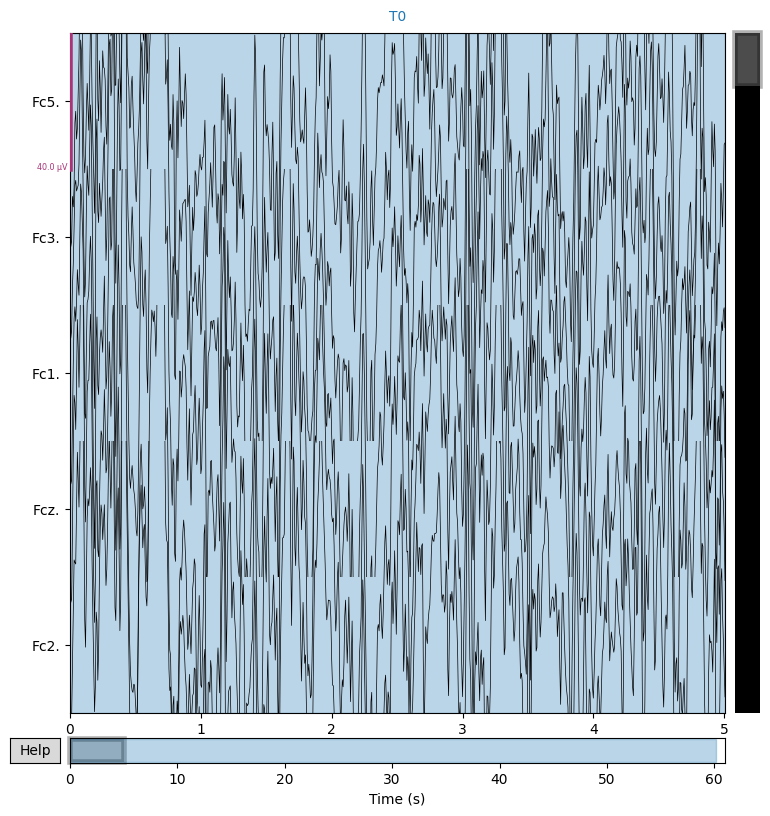

In [1]:
import mne
import numpy as np
import matplotlib.pyplot as plt

# ======================
# 1. Load small EEG dataset
# ======================

files = mne.datasets.eegbci.load_data(subject=1, runs=[1])
raw = mne.io.read_raw_edf(files[0], preload=True)

print("Data loaded")
print(raw.info)

# ======================
# 2. Select EEG channels
# ======================

raw.pick_types(eeg=True)

print("EEG channels:", len(raw.ch_names))

# ======================
# 3. Filtering
# ======================

raw.filter(l_freq=0.5, h_freq=45)

# حذف نویز برق (اگر لازم بود)
raw.notch_filter(freqs=50)

print("Filtering done")

# ======================
# 4. Visualization
# ======================

fig = raw.plot(n_channels=5, duration=5, show=False)
fig.savefig("eeg_plot.png")

print("Plot saved")

# ======================
# 5. Extract data
# ======================

data, times = raw.get_data(return_times=True)

print("EEG shape:", data.shape)

# ======================
# 6. Save outputs
# ======================

np.save("eeg_filtered.npy", data)
np.save("eeg_times.npy", times)

print("Files saved")
print("Done ✅")
